In [1]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from typing import TypedDict,List
from langgraph.graph import StateGraph,START,END,add_messages
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pydantic import BaseModel,Field
from langchain_community.vectorstores import FAISS
from langchain_community.tools.tavily_search import TavilySearchResults

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
loader1 = PyPDFLoader("documents/book1.pdf")
loader2 = PyPDFLoader("documents/book2.pdf")
loader3 = PyPDFLoader("documents/book3.pdf")

In [3]:
docs = loader1.load() + loader2.load() + loader3.load()
len(docs)

2123

In [4]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap = 200
)

chunk = splitter.split_documents(docs)

len(chunk)

5918

In [5]:
load_dotenv()

model = ChatOpenAI()

In [6]:
embedding = OpenAIEmbeddings()

parser = StrOutputParser()

vector_store = FAISS.from_documents(
        embedding=embedding,
        documents=chunk
)

In [7]:
retriever = vector_store.as_retriever(
    search_type = 'mmr',
    serach_kwargs = {'k':4}
)

In [8]:
class RagState(TypedDict,total=False):

    question : str
    documents : List[Document]

    good_docs : List[Document]
    verdict : str
    reason : str

    strip : List[str]
    kept_strip : List[str]
    refined_content : str

    web_docs : List[Document]

    web_query : str

    answer : str

In [9]:
class KeepOrDrop(BaseModel):

    keep : bool = Field(description='True or False')

parser1 = PydanticOutputParser(pydantic_object=KeepOrDrop)

In [10]:
def retrieve(state:RagState)->dict:

    question = state['question']

    response = retriever.invoke(question)

    print('Documents retrieved length of docs is : ',len(response))

    return {'documents':response}

In [11]:
import re

def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [12]:
def refine(state:RagState)->dict:

    #refined_content = state.get('refined_content',"")

    question = state['question']

    #documents = state['documents']
    good_docs = state['good_docs']
    web_docs = state.get('web_docs','')
    verdict = state['verdict']

    if verdict == 'CORRECT':
        context = '\n'.join(f"- {docs.page_content}" for docs in good_docs)
    elif verdict == 'INCORRECT':
        context = '\n'.join(f"- {docs.page_content}" for docs in web_docs)
    else:
        docs_to_use = good_docs + web_docs
        context = '\n'.join(f"- {docs.page_content}" for docs in docs_to_use)

    strips = decompose_to_sentences(context)

    template = ChatPromptTemplate([
        ('system',
         "You are a strict relevance filter.\n"
        "Return keep=true only if the sentence directly helps answer the question.\n"
        "Use ONLY the sentence. Output JSON only. \n"),
        ('user',"Question: {question}\n\nSentence:\n{sentence}")
    ],
    input_variables = ['question','sentence'],
    )

    kept : List[str] =[]

    model_with_structured_output = model.with_structured_output(KeepOrDrop)
    chain = template | model_with_structured_output 
    for s in strips:
        keep_drop : KeepOrDrop = chain.invoke({'question':question,'sentence':s})
        #keep_drop_dict = keep_drop.model_dump()
        if keep_drop.keep:
            kept.append(s)

    refined_content = ''.join(kept).strip()

    print('Refined content generated : ',refined_content)

    return {
        'strips':strips,
        'keep_strip':kept,
        'refined_content':refined_content
    }

In [13]:
def generate(state:RagState)->dict:

    question = state['question']
    refined_content = state['refined_content']
    
    template = ChatPromptTemplate([
        ('system',"You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'"),
        ('user',"Question: {question}\n\nRefined context:\n{refined_content}")
    ],
    input_variables = ['question','refined_context']
    )

    chain = template | model | parser

    response = chain.invoke({'question':question,'refined_content':refined_content})

    print('output generated : ',response)

    return {'answer':response}

In [14]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [15]:
class DocEvalScore(BaseModel):

    score : float
    reason : str

#parser2 = PydanticOutputParser(pydantic_object=DocEvalScore)

template = ChatPromptTemplate([
    ('system',"You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only. \n"),
    ('human',"Question: {question}\n\nChunk:\n{chunk}")
],
input_variables = ['question','chunk'], 
)

model_with_structured_output = model.with_structured_output(DocEvalScore)

chain = template | model_with_structured_output 

def eval_each_node(state:RagState)->dict:

    question = state['question']
    documents = state['documents']

    score : List[float] = []
    reason : List[str] = []
    good_docs : List[Document] = []

    for doc in documents:
        doc_eval_score : DocEvalScore = chain.invoke({'question':question,'chunk':doc.page_content})
        #doc_eval_score_dict = doc_eval_score.model_dump()
        score.append(doc_eval_score.score)
        reason.append(doc_eval_score.reason)

        if doc_eval_score.score > LOWER_TH:
            good_docs.append(doc)

    if any(s > UPPER_TH for s in score):
        print('Correct :')
        return {
            'good_docs':good_docs,
            'verdict':'CORRECT',
            'reason': f"At least one doc score is greater that {UPPER_TH}"
        }
    
    if len(score)>0 and all(s<LOWER_TH for s in score):
        print('Incorrect : ')
        return {
            'good_docs':[],
            'verdict':'INCORRECT',
            'reason': f"All doc score is less than {LOWER_TH}"
        }
    
    print('Ambiguous : ')
    return {
        'good_docs':good_docs,
        'verdict':'AMBIGUOUS',
        'reason': f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}"
    }

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_openai\chat_models\base.py:2181: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [16]:
def conditional_edge(state : RagState)->dict:
    verdict = state['verdict']

    if verdict == 'CORRECT':
        return "refine"
    else:
        return "query_rewrite"

In [17]:
tavily = TavilySearchResults(max_results=5)

def web_search(state:RagState)->dict:
    
    web_query = state.get('web_query')
    print(web_query)

    results = tavily.invoke({'query':web_query})

    web_docs = []
    for r in results or []:

        title = r.get('title','')
        url = r.get('url','')
        content = r.get('content','')

        text = f"TITLE : {title}\n\nURL: {url} \nCONTENT: {content}"

        web_docs.append(Document(page_content=text,metadata={'url':url,'title':title}))

    print("Control is at web search : ",[doc.page_content for doc in web_docs])

    return {'web_docs':web_docs}

C:\Users\Jay Kanakia\AppData\Local\Temp\ipykernel_1120\3406748950.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


In [18]:
class WebQuery(BaseModel):

    query : str

template = ChatPromptTemplate([
        ("system",
                "Rewrite the user question into a web search query composed of keywords.\n"
                "Rules:\n"
                "- Keep it short (6–14 words).\n"
                "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
                "- Do NOT answer the question.\n"
                "- Return JSON with a single key: query"),
        ('human',"Question: {question}")
        ],
        input_variables = ['question']
        )

model_with_structure = model.with_structured_output(WebQuery)

def query_rewrite(state:RagState)->dict:

    question = state['question']

    chain = template | model_with_structure

    response = chain.invoke({'question':question})

    print("Control is at query_rewrite : ",response.query)

    return {'web_query':response.query}

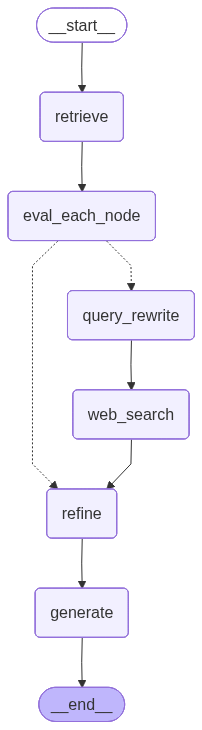

In [19]:
graph = StateGraph(RagState)
graph.add_node('retrieve',retrieve)
graph.add_node('refine',refine)
graph.add_node('generate',generate)
graph.add_node('eval_each_node',eval_each_node)
#graph.add_node('ambiguous',ambiguous)
graph.add_node('web_search',web_search)
graph.add_node('query_rewrite',query_rewrite)

graph.add_edge(START,'retrieve')
graph.add_edge('retrieve','eval_each_node')
graph.add_conditional_edges('eval_each_node',conditional_edge,{'query_rewrite':'query_rewrite','refine':'refine'})
graph.add_edge('query_rewrite','web_search')
graph.add_edge('web_search','refine')
graph.add_edge('refine','generate')
graph.add_edge('generate',END)
#graph.add_edge('ambiguous',END)

chatbot = graph.compile()

chatbot

In [28]:
response = chatbot.invoke({'question':'Recent news on AI in Feb 2026'})

print(response)

Documents retrieved length of docs is :  4
Incorrect : 
Control is at query_rewrite :  AI news February 2026 last 30 days
AI news February 2026 last 30 days
Control is at web search :  ['TITLE : AI News Briefs BULLETIN BOARD for February 2026\n\nURL: https://radicaldatascience.wordpress.com/2026/02/26/ai-news-briefs-bulletin-board-for-february-2026/ \nCONTENT: [2/25/2026] Meta and AMD Partner for Longterm AI Infrastructure Agreement – Meta has partnered with AMD in a multi-year agreement to enhance AI infrastructure with up to 6GW of AMD Instinct GPUs. This collaboration focuses on vertical integration across silicon, systems, and software, aligning roadmaps for scalable AI deployments. Shipments for the first GPU deployments will begin in late 2026, leveraging AMD’s Helios rack-scale architecture for enhanced compute power. [...] [2/11/2026] America’s $1T AI Gamble – The US economy is buoyed by the AI boom, but nowhere near entirely driven by it. The tech industry’s investments in AI 

In [29]:
print(response['verdict'])
print('*'*100)
print(response['reason'])
print('*'*100)
print(response['web_query'])
print('*'*100)
print(response['answer'])

INCORRECT
****************************************************************************************************
All doc score is less than 0.3
****************************************************************************************************
AI news February 2026 last 30 days
****************************************************************************************************
In February 2026, there were significant developments in the field of AI. Some of the key highlights include Meta partnering with AMD for AI infrastructure enhancement, ByteDance generating hyper-realistic deepfake videos leading to legal challenges, Ailias creating full conversational 3D holograms of historical figures, OpenAI launching "Frontier" as an enterprise agent platform, Microsoft pushing Copilot Tasks into background cloud execution, and SpaceX acquiring xAI for $250 billion.


In [30]:
response['refined_content']

"- TITLE : AI News Briefs BULLETIN BOARD for February 2026 URL: https://radicaldatascience.wordpress.com/2026/02/26/ai-news-briefs-bulletin-board-for-february-2026/ CONTENT: [2/25/2026] Meta and AMD Partner for Longterm AI Infrastructure Agreement – Meta has partnered with AMD in a multi-year agreement to enhance AI infrastructure with up to 6GW of AMD Instinct GPUs.This collaboration focuses on vertical integration across silicon, systems, and software, aligning roadmaps for scalable AI deployments.Shipments for the first GPU deployments will begin in late 2026, leveraging AMD’s Helios rack-scale architecture for enhanced compute power.[...] [2/11/2026] America’s $1T AI Gamble – The US economy is buoyed by the AI boom, but nowhere near entirely driven by it.These decisions could dictate how future AIs treat humans.- TITLE : February 2026 AI News Roundup: Scale-Up and Shakeup, Funding ...URL: https://www.ptechpartners.com/2026/03/03/february-2026-ai-news-roundup-scale-up-and-shakeup-fu